## Customer Segmentation

### Step 1- Load and Inspect Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

data = pd.read_csv("Mall_Customers.csv")
print(data.head())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### Step 2- Missing Values Check

In [2]:
missing_vals = data[["Age","Annual Income (k$)","Spending Score (1-100)"]].isna().sum()
print("Missing Age:", missing_vals["Age"])
print("Missing Income:", missing_vals["Annual Income (k$)"])
print("Missing Score:", missing_vals["Spending Score (1-100)"])


Missing Age: 0
Missing Income: 0
Missing Score: 0


### Step 3- Scatter Plot

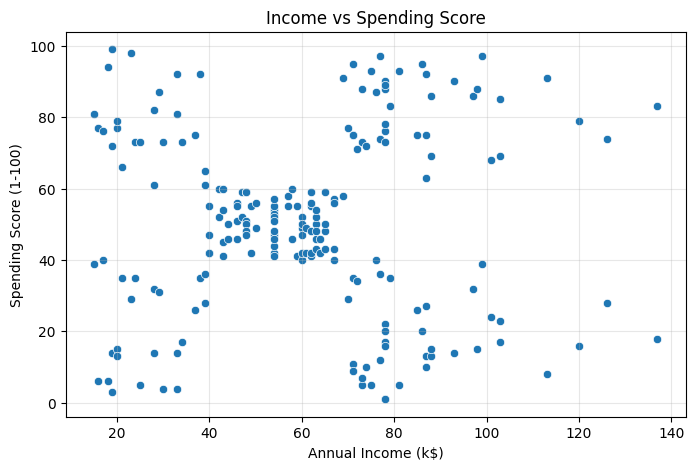

In [3]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=data)
plt.title("Income vs Spending Score")
plt.grid(alpha=0.3)
plt.show()


### Step 4- Correlation Heatmap

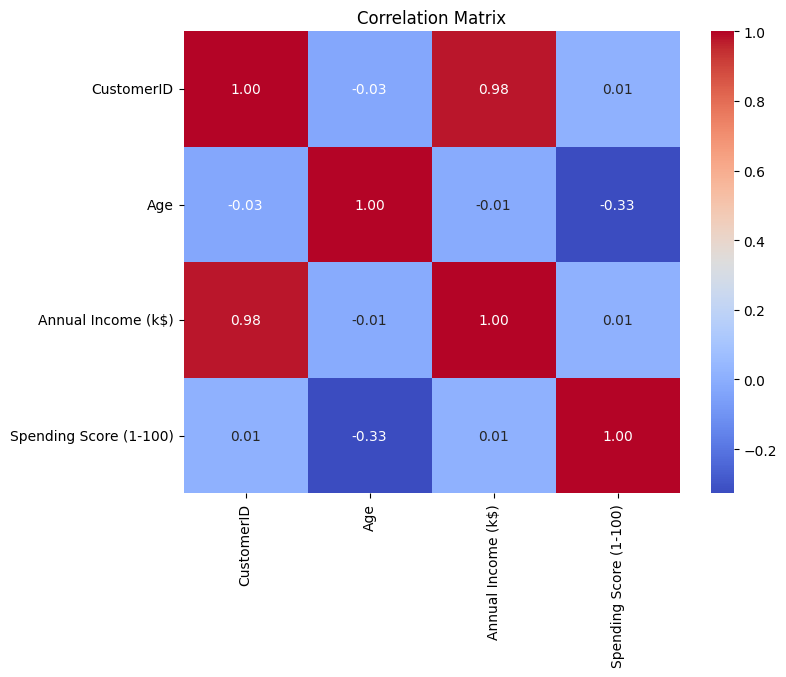

ValueError: underlying array is read-only

In [5]:
import numpy as np
corr = data.select_dtypes(include="number").corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Find strongest pair
temp_corr = corr.copy()
np.fill_diagonal(temp_corr.values, 0)
pair = temp_corr.abs().stack().idxmax()
value = corr.loc[pair[0], pair[1]]

print("Strongest correlation:", pair, "=", round(value,2))


### Step 5- KMeans Clustering

In [6]:
X = data[["Annual Income (k$)","Spending Score (1-100)"]]
km = KMeans(n_clusters=3, random_state=42, n_init=10)
data["Cluster"] = km.fit_predict(X)

print(data.head(10))


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  
5        2  
6        2  
7        2  
8        2  
9        2  


### Step 6- Cluster Sizes

In [7]:
print(data["Cluster"].value_counts().sort_index())


Cluster
0     38
1     39
2    123
Name: count, dtype: int64
